# Ex. No: 07 
## Lane Detection using Hough Transform.

**Name :** MITHUN S    **Reg. No :** 212224240088    **Slot No :** 26OD1199

In [42]:
# Import 
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [43]:
image = cv2.imread('lan_img1.jpg')

In [44]:
img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

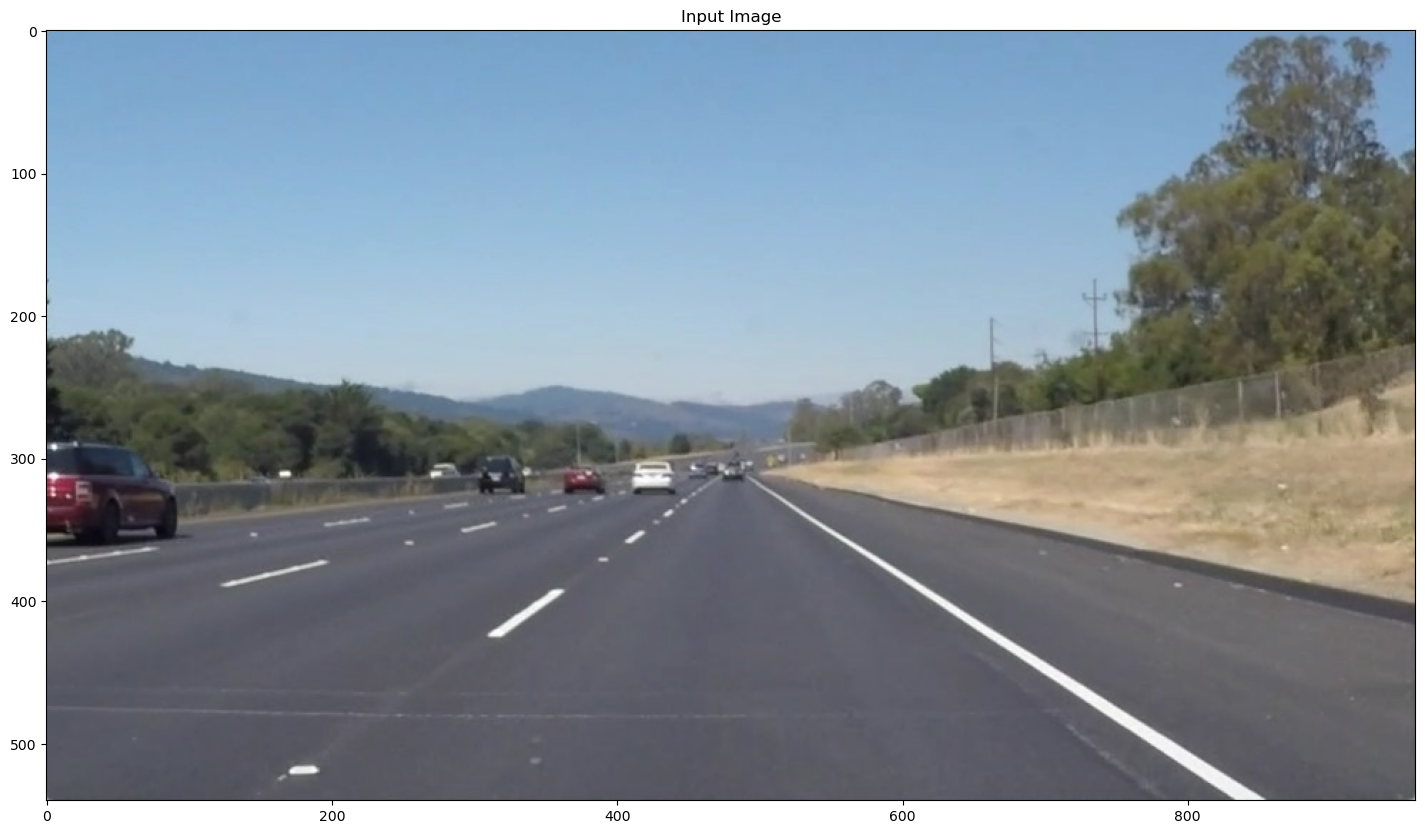

In [45]:
plt.figure(figsize = (20, 10))
plt.imshow(img)
plt.title('Input Image')
plt.show()

Text(0.5, 1.0, 'Grayscale')

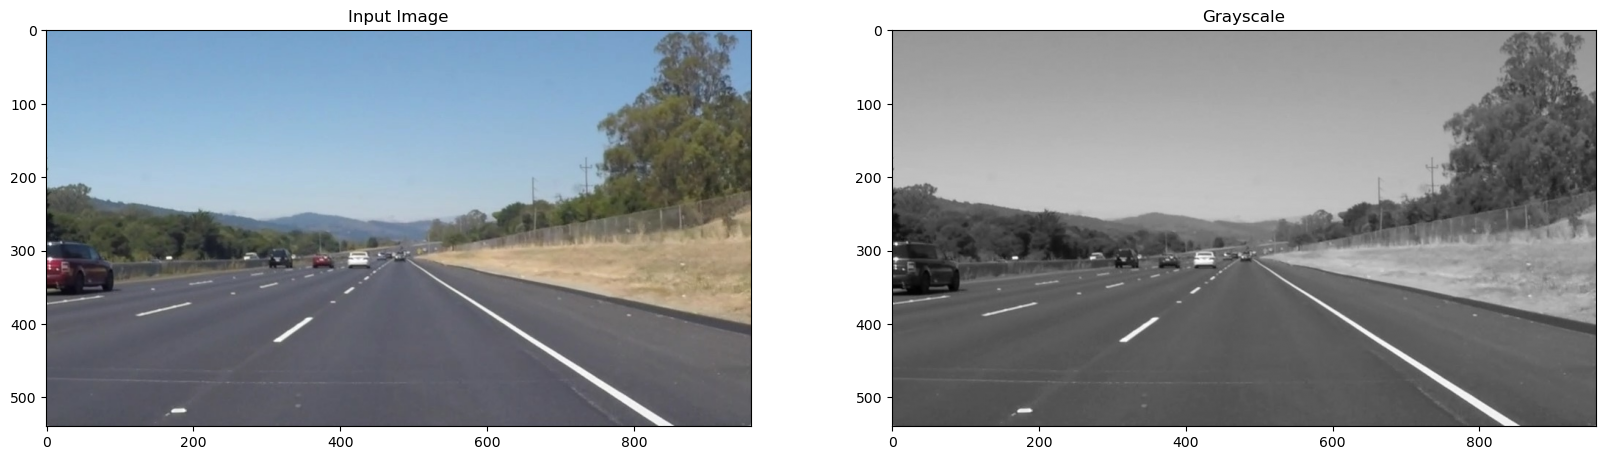

In [46]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.figure(figsize = (20, 10))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title('Input Image')

plt.subplot(1,2,2)
plt.imshow(gray, cmap='gray')
plt.title('Grayscale')

In [47]:
threshold = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)[1]

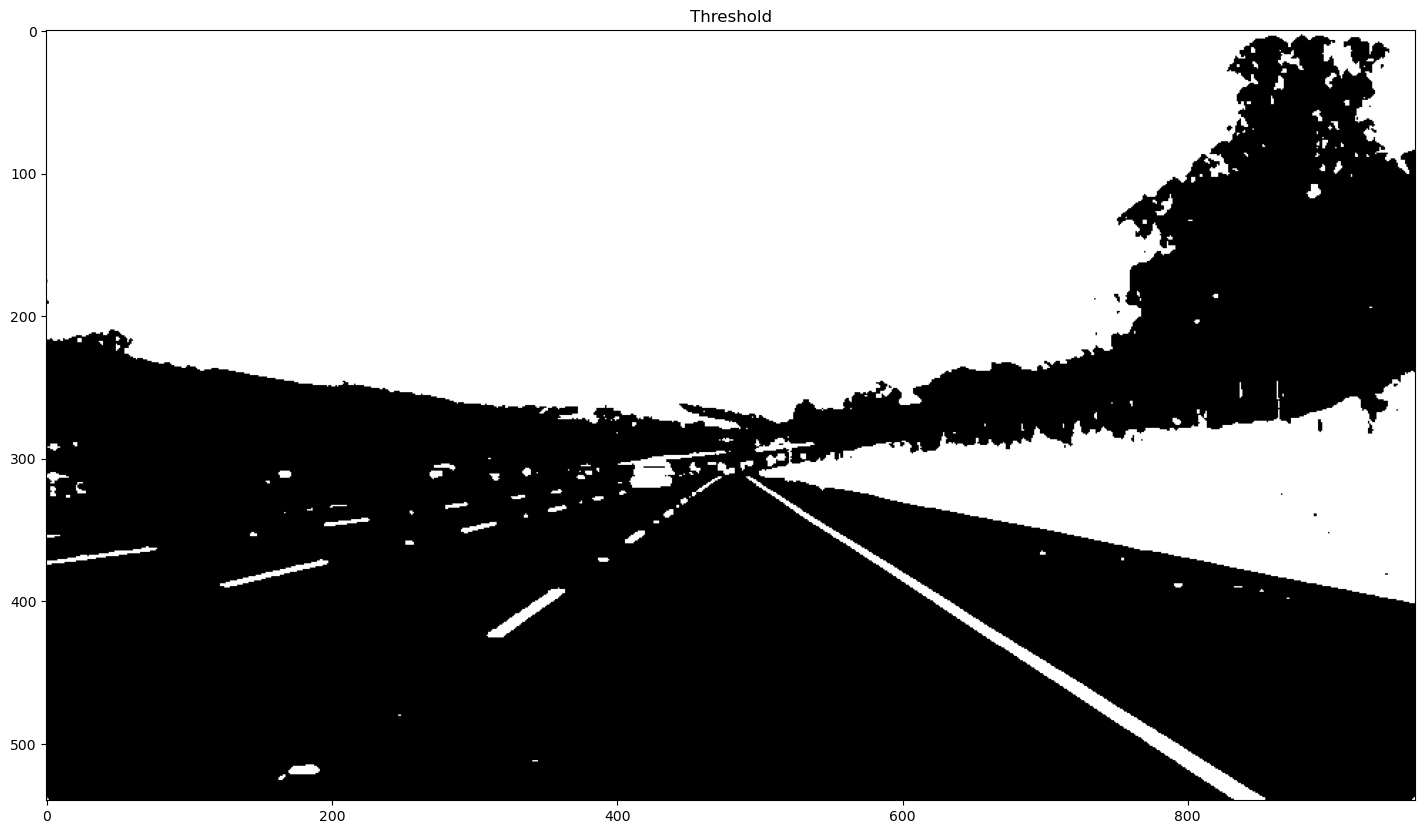

In [48]:
# Expected Output
# Display images.
plt.figure(figsize = (20, 10))
plt.subplot(1,1,1);
plt.imshow(threshold, cmap='gray')
plt.title('Threshold')
plt.show()

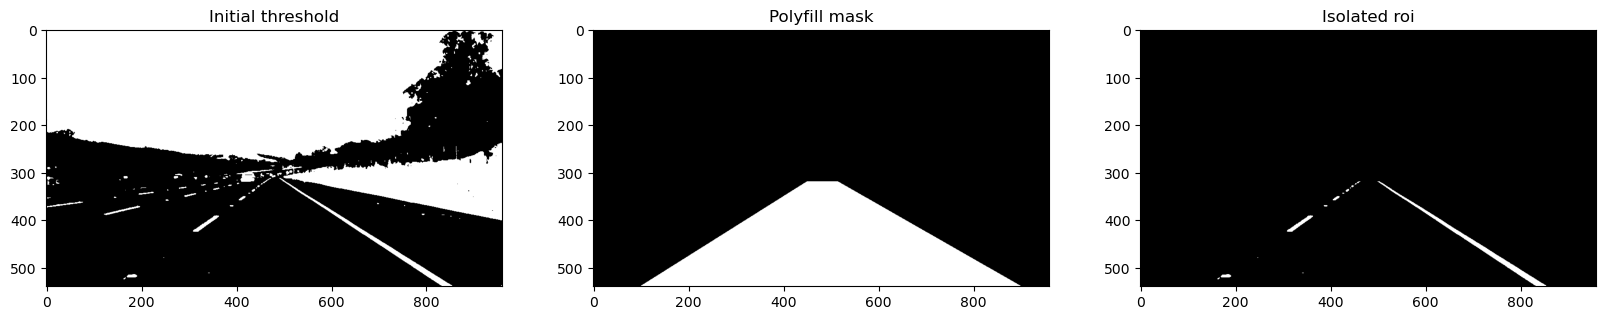

In [49]:
#  Region masking: Select vertices according to the input image.
roi_vertices = np.array([[[100, 540],
                          [900, 540],
                          [515, 320],
                          [450, 320]]])

# Defining a blank mask.
mask = np.zeros_like(threshold)   

# Defining a 3 channel or 1 channel color to fill the mask.
if len(threshold.shape) > 2:
    channel_count = threshold.shape[2]  # 3 or 4 depending on the image.
    ignore_mask_color = (255,) * channel_count
else:
    ignore_mask_color = 255

# Filling pixels inside the polygon.
cv2.fillPoly(mask, roi_vertices, ignore_mask_color)

# Constructing the region of interest based on where mask pixels are nonzero.
roi = cv2.bitwise_and(threshold, mask)

# Display images.
plt.figure(figsize = (20, 10))
plt.subplot(1,3,1); plt.imshow(threshold, cmap = 'gray'); plt.title('Initial threshold')
plt.subplot(1,3,2); plt.imshow(mask, cmap = 'gray');      plt.title('Polyfill mask')
plt.subplot(1,3,3); plt.imshow(roi, cmap = 'gray');       plt.title('Isolated roi');

In [50]:
edges = cv2.Canny(roi, 50, 150)

In [51]:
canny_blur = cv2.GaussianBlur(edges, (5, 5), 0)

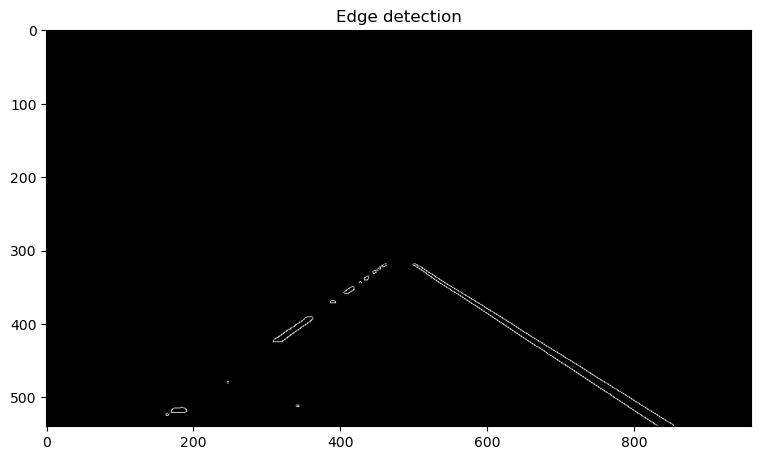

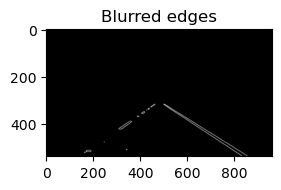

In [52]:
# Expected Output
# Display images.
plt.figure(figsize = (20, 10))

plt.subplot(1,2,1); 
plt.imshow(edges, cmap = 'gray'); 
plt.title('Edge detection')
plt.show()

plt.subplot(1,2,2);
plt.imshow(canny_blur, cmap = 'gray'); 
plt.title('Blurred edges');
plt.show()

In [53]:
def draw_lines(img, lines, color=(255, 0, 0), thickness=2):
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line
            cv2.line(img, (x1, y1), (x2, y2), color, thickness)

In [54]:
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 100, minLineLength=50, maxLineGap=10)

Found 2 lines, including: [503 319 854 538]


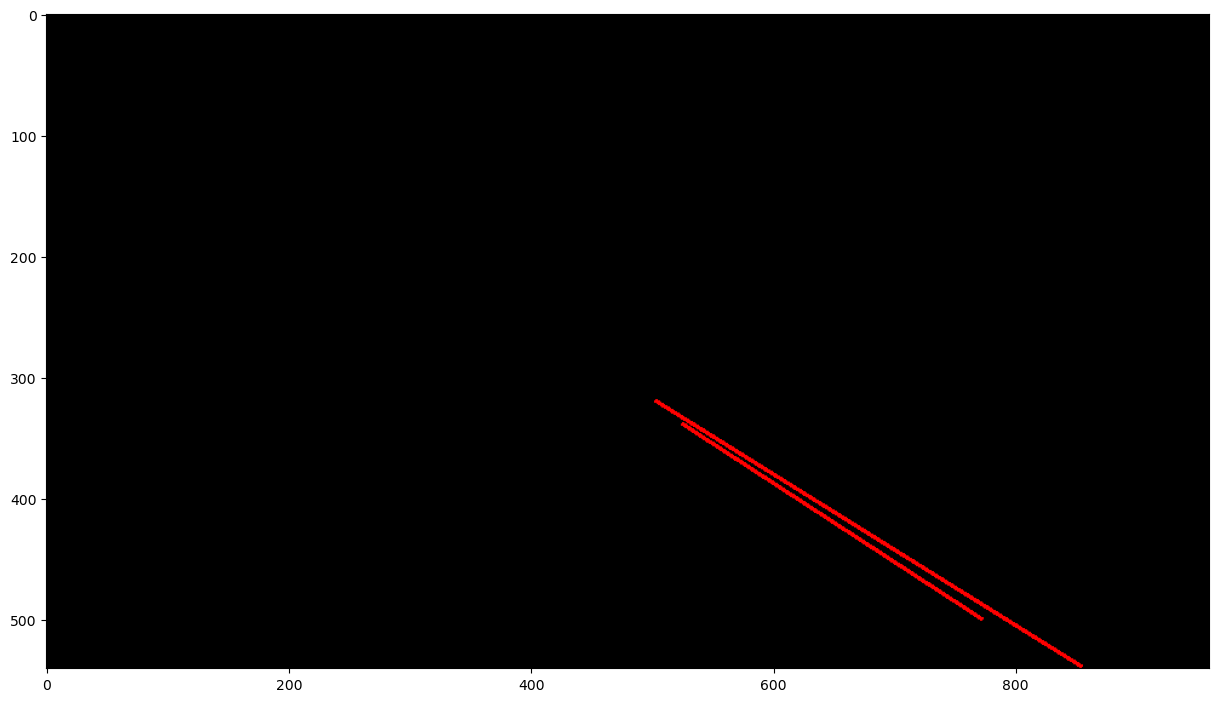

In [55]:
hough = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)

draw_lines(hough, lines)

print("Found {} lines, including: {}".format(len(lines), lines[0]))

plt.figure(figsize=(15, 10))
plt.imshow(hough)
plt.show()

In [56]:
def separate_left_right_lines(lines):
    left_lines = []
    right_lines = []

    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line

            if x1 == x2:
                continue

            slope = (y2 - y1) / (x2 - x1)

            if slope < 0:
                left_lines.append([x1, y1, x2, y2])
            else:
                right_lines.append([x1, y1, x2, y2])

    return left_lines, right_lines

In [57]:
def cal_avg(values):
    """Calculate average value."""
    if not (type(values) == 'NoneType'):
        if len(values) > 0:
            n = len(values)
        else:
            n = 1
        return sum(values) / n

In [58]:
def extrapolate_lines(lines, upper_border, lower_border):
    """Extrapolate lines keeping in mind the lower and upper border intersections."""
    slopes = []
    consts = []
    
    if lines is not None:
        for x1, y1, x2, y2 in lines:
            slope = (y1-y2) / (x1-x2)
            slopes.append(slope)
            c = y1 - slope * x1
            consts.append(c)
    avg_slope = cal_avg(slopes)
    avg_consts = cal_avg(consts)
    
    # Calculate average intersection at lower_border.
    x_lane_lower_point = int((lower_border - avg_consts) / avg_slope)
    
    # Calculate average intersection at upper_border.
    x_lane_upper_point = int((upper_border - avg_consts) / avg_slope)
    
    return [x_lane_lower_point, lower_border, x_lane_upper_point, upper_border]

In [59]:
def extrapolate_lines(lines, upper_border, lower_border):
    slopes = []
    consts = []

    if lines is not None and len(lines) > 0:
        for x1, y1, x2, y2 in lines:
            if x1 == x2:
                continue

            slope = (y2 - y1) / (x2 - x1)
            slopes.append(slope)

            c = y1 - slope * x1
            consts.append(c)

    if len(slopes) == 0:
        return [0, lower_border, 0, upper_border]

    avg_slope = cal_avg(slopes)
    avg_consts = cal_avg(consts)

    x_lane_lower_point = int((lower_border - avg_consts) / avg_slope)
    x_lane_upper_point = int((upper_border - avg_consts) / avg_slope)

    return [x_lane_lower_point, lower_border,
            x_lane_upper_point, upper_border]

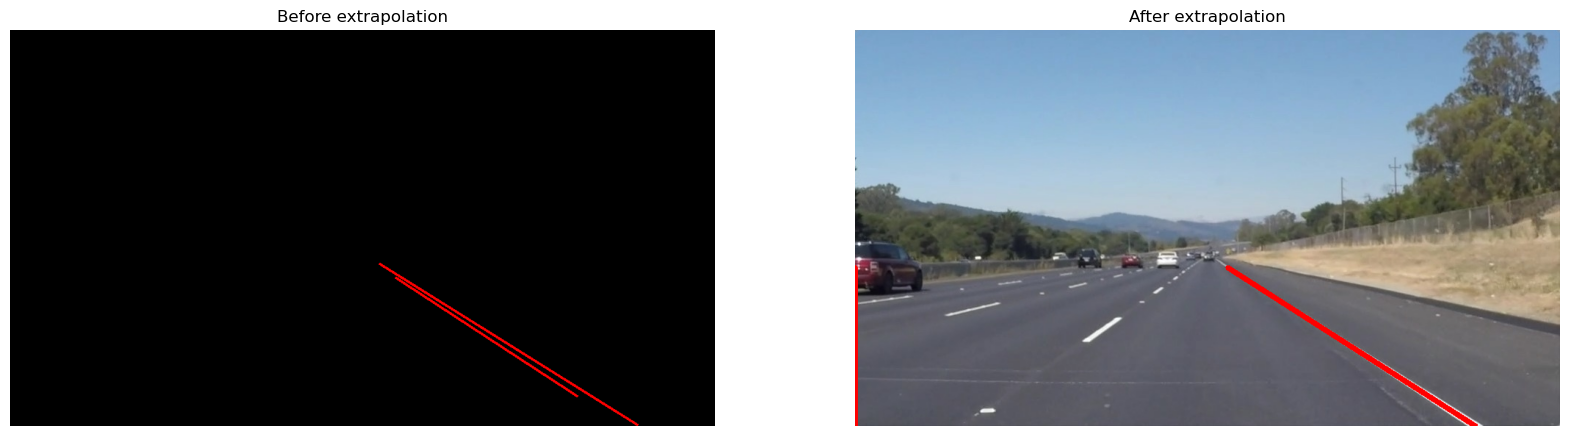

In [60]:
# Separate detected lines into left and right lanes
left_lines, right_lines = separate_left_right_lines(lines)

# Image boundaries
upper_border = int(img.shape[0] * 0.6)
lower_border = img.shape[0]

# Extrapolate left and right lane lines
left_lane = extrapolate_lines(left_lines, upper_border, lower_border)
right_lane = extrapolate_lines(right_lines, upper_border, lower_border)

# Create a copy of the original image
lan_img1 = img.copy()

# Draw extrapolated lane lines
draw_lines(
    lan_img1,
    [left_lane],
    color=(255, 0, 0),
    thickness=5
)

draw_lines(
    lan_img1,
    [right_lane],
    color=(255, 0, 0),
    thickness=5
)

# Display both results
fig = plt.figure(figsize=(20, 10))

# Before extrapolation
ax = fig.add_subplot(1, 2, 1)
plt.imshow(hough)
ax.set_title("Before extrapolation")
ax.axis("off")

# After extrapolation
ax = fig.add_subplot(1, 2, 2)
plt.imshow(lan_img1)
ax.set_title("After extrapolation")
ax.axis("off")

plt.show()